# Landing Page

In [8]:
# ONC Statistics

import os
import pandas as pd
import numpy as np
from datetime import date
from dotenv import load_dotenv
from onc.onc import ONC

load_dotenv()

# Initialize ONC API
onc = ONC(os.getenv("ONC_API_TOKEN"))

# Efficiently fetch all hydrophone deployments in one go
# This replaces the for-loop for much faster rendering
response = onc.getDeployments({"deviceCategoryCode": "HYDROPHONE"})
df_depl = pd.DataFrame(response)
ds_depl = df_depl.to_xarray()

# Calculate stats
# Filter for unique devices and locations
nh = ds_depl.where(ds_depl.end==None, drop=True).locationCode.size
nl = df_depl['locationCode'].nunique()

# Current date
today_str = date.today().strftime('%B %d, %Y')

# Output the sentence directly into the Markdown
print(f"As of {today_str}, ONC manages **{nh} hydrophones** across spanning the Pacific, Atlantic, and Arctic coasts.")

As of April 22, 2026, ONC manages **95 hydrophones** across **85 locations** spanning the Pacific, Atlantic, and Arctic coasts.


# Network Overview

In [61]:
HANDBOOK_PATH = '/Users/ebeaudin/Desktop/Hydrophones/handbook'

In [62]:
all_ds = ds_depl
active_ds = ds_depl.where(ds_depl.end.isnull(), drop=True)
df_temp = all_ds.to_dataframe().reset_index()

df_export = df_temp.groupby('locationCode').agg({
    'lat': 'first',
    'lon': 'first',
    'depth': 'first',
    'active': 'first',
}).reset_index()

# save to CSV
df_export.to_csv(f'{HANDBOOK_PATH}/notebooks/hydrophone_locations.csv', index=False)

print(f"Exported {len(df_export)} active locations with coordinates to CSV.")

KeyError: "Column(s) ['active'] do not exist"

In [53]:
names_df = pd.read_csv('location_names.txt', names=['locationCode', 'locationName'])

df_all = ds_depl.to_dataframe().reset_index()

# 2. Determine 'active' status 
# A site is active if its 'end' date is null (NaN)
df_all['active_status'] = df_all['end'].isnull()

# 3. Group by location to get site summaries
# We use 'max' for active_status: if ANY deployment at that site is null, the site is active
df_export = df_all.groupby('locationCode').agg({
    'lat': 'last',
    'lon': 'last',
    'depth': 'last',
    'active_status': 'max' 
}).reset_index()

# 4. Merge the Names from the .txt file
df_export = df_export.merge(names_df, on='locationCode', how='left')
df_export['locationName'] = df_export['locationName'].fillna(df_export['locationCode'])

# 5. Save the final CSV
df_export.to_csv('notebooks/hydrophone_locations.csv', index=False)

In [57]:
import plotly.express as px

# 1. Prepare the deployment data
df_all = ds_depl.to_dataframe().reset_index()

# 2. Add the 'active' logic (Green if end is null, Grey otherwise)
df_all['active_status'] = df_all['end'].isnull()

# 3. Group by location for the dots
df_plot = df_all.groupby('locationCode').agg({
    'lat': 'last',
    'lon': 'last',
    'depth': 'last',
    'active_status': 'max' # True if any deployment at this site is currently active
}).reset_index()

# 4. Merge with your cleaned names_df
df_plot = df_plot.merge(names_df, on='locationCode', how='left')
df_plot['locationName'] = df_plot['locationName'].fillna(df_plot['locationCode'])

# 5. Create a pretty hover label
df_plot['hover_text'] = (
    "<b>" + df_plot['locationName'] + "</b><br>" +
    "Depth: " + df_plot['depth'].astype(str) + "m<br>" +
    "Code: " + df_plot['locationCode']
)

# 6. Plot
fig = px.scatter_mapbox(
    df_plot, 
    lat="lat", 
    lon="lon", 
    color="active_status",
    hover_name="locationName",
    hover_data={
        "lat": False, "lon": False, "active_status": False, 
        "depth": True, "locationCode": True
    },
    color_discrete_map={True: "#28a745", False: "#adb5bd"}, # Green vs Grey
    zoom=3, 
    height=600
)

# 7. Final layout tweaks
fig.update_layout(
    mapbox_style="carto-positron", 
    margin={"r":0,"t":0,"l":0,"b":0},
    showlegend=True,
    legend_title_text='System Status',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

# Rename legend labels for clarity
fig.for_each_trace(lambda t: t.update(name="Active" if t.name == "True" else "Inactive"))

fig.show()

/var/folders/b5/lttcpwhn4ld1jqgqhlcchs_9cpgb9k/T/ipykernel_13027/2877929711.py:29: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [93]:
import pandas as pd
import numpy as np
import plotly.express as px
import os

import os
import pandas as pd
import numpy as np
from datetime import date
from dotenv import load_dotenv
from onc.onc import ONC

load_dotenv()

# Initialize ONC API
onc = ONC(os.getenv("ONC_API_TOKEN"))

HANDBOOK_PATH = '/Users/ebeaudin/Desktop/Hydrophones/handbook'

# get all hydrophone deployments
response = onc.getDeployments({"deviceCategoryCode": "HYDROPHONE"})
df_depl = pd.DataFrame(response)
ds_depl = df_depl.to_xarray()

# load the location names from text file
names_df = pd.read_csv(f'{HANDBOOK_PATH}/notebooks/location_names.txt', header=None, names=['locationCode','locationName'])

df_all = df_depl.reset_index().sort_values('begin')
df_all['active_status'] = df_all['end'].isnull() # add status

df_plot = df_all.groupby('locationCode').agg({
    'lat': 'last',
    'lon': 'last',
    'depth': 'last',
    'active_status': 'max',
    'deviceCode': 'last' 
}).reset_index()

# Merge the Names
df_plot = df_plot.merge(names_df, on='locationCode', how='left')
df_plot['locationName'] = df_plot['locationName'].fillna(df_plot['locationCode'])

df_plot['lat'] = pd.to_numeric(df_plot['lat'], errors='coerce')
df_plot['lon'] = pd.to_numeric(df_plot['lon'], errors='coerce')

df_plot['hover_text'] = [
    f"{row['locationName']}<br>"
    f"<b>Location Code:</b> {row['locationCode']}<br>"
    # Show deviceCode only if active_status is True, otherwise show "--"
    f"<b>Device Code:</b> {row['deviceCode'] if row['active_status'] else '--'}<br>"
    f"<b>Depth:</b> {row['depth']} m<br>"
    f"<b>Coords:</b> {row['lat']:.2f}, {row['lon']:.2f}"
    for _, row in df_plot.iterrows()
]

# plot with mapbox
fig = px.scatter_mapbox(
    df_plot, 
    lat="lat", 
    lon="lon", 
    color="active_status",
    color_discrete_map={True: "#28a745", False: "#adb5bd"},
    custom_data=['hover_text'],
    hover_name="locationName",
    zoom=2.2, 
    center={"lat": 58, "lon": -95}
)

fig.update_traces(
    hovertemplate="%{customdata[0]}<extra></extra>",
    marker_size=16,
)

# 3. Layout (Map style and Legend)
fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0,"t":0,"l":0,"b":0},
    height=600,
    legend=dict(
        title="<b>Network Status</b>",
        yanchor="top", y=0.95,
        xanchor="left", x=0.02,
        bgcolor="rgba(255, 255, 255, 0.6)"
    )
)

# legend names
fig.for_each_trace(lambda t: t.update(name="Active" if t.name == "True" else "Inactive"))

fig.show()

/var/folders/b5/lttcpwhn4ld1jqgqhlcchs_9cpgb9k/T/ipykernel_13027/2944662089.py:70: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [87]:
i=2

df_plot.locationName[i], str(df_plot.lat[i]), str(df_plot.lon[i]), 

('Barkley Node Hydrophone A', '48.345174', '-126.157316')

In [90]:
print(df_plot[['lat','lon']].describe())

             lat         lon
count  85.000000   85.000000
mean   49.184241 -124.362593
std     2.498202    8.403694
min    47.425510 -130.431140
25%    48.426393 -126.872425
50%    48.813851 -125.274707
75%    49.043358 -123.329648
max    69.112468  -53.121068


# How do hydrophones work?

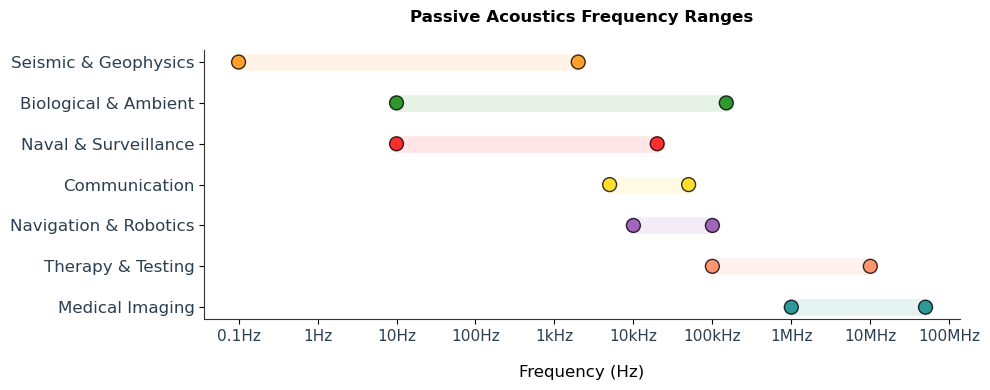

In [169]:
import matplotlib.pyplot as plt
import numpy as np

data = [
    {"cat": "Seismic & Geophysics", "low": 0.1, "high": 2000, "color": "darkorange"},
    {"cat": "Biological & Ambient", "low": 10, "high": 150000, "color": "green"},
    {"cat": "Naval & Surveillance", "low": 10, "high": 20000, "color": "red"},
    {"cat": "Communication", "low": 5000, "high": 50000, "color": "gold"},
    {"cat": "Navigation & Robotics", "low": 10000, "high": 100000, "color": "#8e44ad"},
    {"cat": "Therapy & Testing", "low": 100000, "high": 10000000, "color": "coral"},
    {"cat": "Medical Imaging", "low": 1000000, "high": 50000000, "color": "teal"}
]


# sort data lowest frequency at top
data.sort(key=lambda x: x["low"], reverse=False)

# sound categories
categories = [d["cat"] for d in data]
values_low = [d["low"] for d in data]
values_high = [d["high"] for d in data]
y_pos = np.arange(len(categories))
colors = [d["color"] for d in data]

# plot
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)

# sound categories
ax.hlines(y=y_pos, xmin=values_low, xmax=values_high, color=colors, linewidth=12, alpha=0.1, capstyle='round')
ax.scatter(values_low, y_pos, color=colors, s=100, zorder=3, edgecolors='k', alpha=0.8)
ax.scatter(values_high, y_pos, color=colors, s=100, zorder=3, edgecolors='k', alpha=0.8)

ax.set_xscale('log')
ax.invert_yaxis()

ax.spines['top'].set_visible(False) # remove spines
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333')
ax.spines['bottom'].set_color('#333')

ax.set_yticks(y_pos)
ax.set_yticklabels(categories, fontsize=12, color='#2c3e50')

xticks = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000]
xtick_labels = ['0.1Hz', '1Hz', '10Hz', '100Hz', '1kHz', '10kHz', '100kHz', '1MHz', '10MHz', '100MHz']
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, fontsize=11, color='#2c3e50')

ax.set_xlabel('Frequency (Hz)', fontsize=12, labelpad=15)
ax.set_title('Passive Acoustics Frequency Ranges', loc='center', weight='bold', fontsize=12, pad=20)

plt.tight_layout()
plt.show()

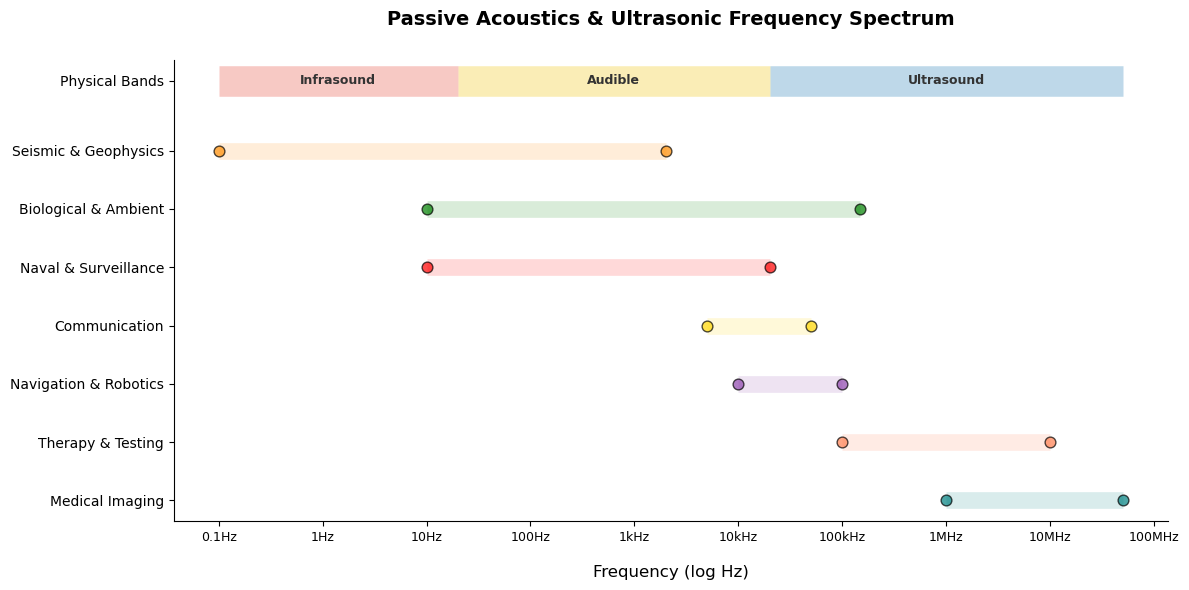

In [180]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# --- Data Preparation ---
data = [
    {"cat": "Seismic & Geophysics", "low": 0.1, "high": 2000, "color": "darkorange"},
    {"cat": "Biological & Ambient", "low": 10, "high": 150000, "color": "green"},
    {"cat": "Naval & Surveillance", "low": 10, "high": 20000, "color": "red"},
    {"cat": "Communication", "low": 5000, "high": 50000, "color": "gold"},
    {"cat": "Navigation & Robotics", "low": 10000, "high": 100000, "color": "#8e44ad"},
    {"cat": "Therapy & Testing", "low": 100000, "high": 10000000, "color": "coral"},
    {"cat": "Medical Imaging", "low": 1000000, "high": 50000000, "color": "teal"}
]

freq_bands = [
    {'cat': 'Infrasound', 'low': 0.1, 'high': 20, 'color': '#e74c3c'},
    {'cat': 'Audible', 'low': 20, 'high': 20000, 'color': '#f1c40f'},
    {'cat': 'Ultrasound', 'low': 20000, 'high': 50000000, 'color': '#2980b9'},
    #{'cat': 'Hypersound', 'low': 5e8, 'high': 1e10, 'color': '#95a5a6'},
]

# Sort applications by lowest frequency
data.sort(key=lambda x: x["low"])

# Setup vertical positions
band_y = 0  # All physical bands go on line 0
gap = 1.2
app_y = np.arange(len(data)) + gap

# --- Plotting ---
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# 1. Plot Physical Frequency Bands (All on one line, squared edges)
for d in freq_bands:
    # capstyle='butt' provides the squared edges
    ax.hlines(y=band_y, xmin=d['low'], xmax=d['high'], color=d['color'], 
              linewidth=22, alpha=0.3, capstyle='butt')
    
    # Label the bands in the center of their segment
    # (Using geometric mean for better centering on a log scale)
    midpoint = np.sqrt(d['low'] * d['high'])
    ax.text(midpoint, band_y, d['cat'], ha='center', va='center', 
            fontsize=9, fontweight='bold', color='#333')

# 2. Plot Applications (Separate lines, squared edges)
for i, d in enumerate(data):
    ax.hlines(y=app_y[i], xmin=d['low'], xmax=d['high'], color=d['color'], 
              linewidth=12, alpha=0.15, capstyle='butt')
    ax.scatter([d['low'], d['high']], [app_y[i], app_y[i]], color=d['color'], 
               s=60, zorder=3, edgecolors='k', alpha=0.7)

# --- Styling ---
ax.set_xscale('log')
ax.invert_yaxis() 

# Setting Y-axis Labels
ax.set_yticks(np.append([band_y], app_y))
ax.set_yticklabels(['Physical Bands'] + [d['cat'] for d in data], 
                   fontsize=10)

# X-Axis Tick Formatting
xticks = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000]
xtick_labels = ['0.1Hz', '1Hz', '10Hz', '100Hz', '1kHz', '10kHz', '100kHz', '1MHz', '10MHz', '100MHz']
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, fontsize=9)
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1, 10)))

for s in ['top', 'right']: ax.spines[s].set_visible(False) # spines
    
ax.set_xlabel('Frequency (log Hz)', fontsize=12, labelpad=15)
ax.set_title('Passive Acoustics & Ultrasonic Frequency Spectrum', weight='bold', fontsize=14, pad=25)

plt.tight_layout()
plt.show()